# Web of Life — analisi reti pianta-impollinatore (versione ottimizzata)

Rifà l'analisi di `test_wol.ipynb` sui dati `data/data_wol/file_bipatite` (174 reti
originali; **158 reti con ≥ 20 nodi** utilizzate nell'analisi dopo il filtraggio iniziale).
Pipeline: costruzione grafi vettorizzata, matrice di distanze Wasserstein a classi calcolata
in O(n) (precalcolo delle distribuzioni per-rete), regione biogeografica derivata da lat/lon,
test statistici (PERMANOVA / Mantel / ANOSIM) e confronto con la distanza Wasserstein whole-graph.

In [27]:
import sys, os, glob, time
sys.path.insert(0, r"C:\Users\Utente\Desktop\progetto vscode\src")

import numpy as np
import pandas as pd
import networkx as nx
import ot
import matplotlib.pyplot as plt
import seaborn as sns

from functions import node_embedding

from skbio.stats.distance import DistanceMatrix, permanova, mantel, anosim
from scipy.spatial.distance import pdist, squareform

## 1. Costruzione grafi bipartiti (vettorizzata)

Legge un CSV (matrice piante × impollinatori), aggiunge i nodi con attributo `bipartite`
(anche le specie isolate) e crea gli archi **solo dai non-zero** con `df[df>0].stack()`,
evitando il doppio `for` O(P×I) dell'originale.

In [28]:
def create_bipartite_graph(file_path):
    df = pd.read_csv(file_path, index_col=0, sep=',')
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    plants = df.index.tolist()
    pollinators = df.columns.tolist()

    G = nx.Graph()
    G.add_nodes_from(plants, bipartite=0)
    G.add_nodes_from(pollinators, bipartite=1)

    # stack() sul df DOPO fillna(0): nessun NaN nel df, quindi il risultato è pulito.
    # df[df > 0].stack() mascherava gli zeri come NaN e in pandas >= 2.2
    # il default di dropna è cambiato: i NaN finivano come pesi negli archi (nan > 0 è False).
    s = df.stack()
    s = s[s > 0]
    G.add_weighted_edges_from((p, i, float(w)) for (p, i), w in s.items())

    nodes = list(G.nodes())
    partition_plant = [k for k, n in enumerate(nodes) if G.nodes[n]['bipartite'] == 0]
    partition_pollinators = [k for k, n in enumerate(nodes) if G.nodes[n]['bipartite'] == 1]

    return G, partition_plant, partition_pollinators, plants, pollinators

## 2. Caricamento grafi ed embedding iniziale

Per ogni CSV: crea il grafo bipartito, salva l'ID (`M_PL_xxx`) e calcola l'embedding a
classi con `node_embedding`. Grafi ed embedding sono indicizzati **per ID**.
Immediatamente dopo viene applicato un **filtro**: le reti con meno di `MIN_NODES` nodi
vengono rimosse da `graph_ids`, `graphs` ed `embeddings`, così tutte le analisi successive
(distanza a classi, test statistici, distanze whole-graph) operano solo sulle reti
sufficientemente grandi (158 reti con ≥ 20 nodi).

In [29]:
def adaptive_dim(n_nodes):
    if n_nodes < 100:
        return max(2, int(n_nodes / 5))
    return max(2, int(n_nodes / 10))

In [30]:
folder = r"C:\Users\Utente\Desktop\progetto vscode\data\data_wol\file_bipatite"
path_files = sorted(glob.glob(os.path.join(folder, "*.csv")))
print(f"{len(path_files)} reti trovate")

graphs = {}        # id -> grafo
embeddings = {}    # id -> X_list ([X_piante, X_impollinatori])
graph_ids = []     # ordine di elaborazione

t0 = time.time()
for f in path_files:
    gid = os.path.basename(f).replace('.csv', '')
    g, ppl, ppo, plants, pollinators = create_bipartite_graph(f)
    g.graph['name'] = gid
    X_list = node_embedding(g, [ppl, ppo], adaptive_dim(len(g.nodes())))
    graphs[gid] = g
    embeddings[gid] = X_list
    graph_ids.append(gid)
print(f"Embedding di {len(graph_ids)} reti in {time.time() - t0:.1f}s")

174 reti trovate
Embedding di 174 reti in 8.9s


In [31]:
# Rimuove le reti con meno di 15 nodi da tutta l'analisi
MIN_NODES = 20
n_before = len(graph_ids)
excluded = {gid for gid in graph_ids if len(graphs[gid].nodes()) < MIN_NODES}

graph_ids  = [gid for gid in graph_ids if gid not in excluded]
graphs     = {gid: g for gid, g in graphs.items()     if gid not in excluded}
embeddings = {gid: e for gid, e in embeddings.items() if gid not in excluded}

print(f"Soglia: ≥ {MIN_NODES} nodi  |  reti mantenute: {len(graph_ids)} / {n_before}")
if excluded:
    print(f"Esclusi ({len(excluded)}): " + ", ".join(sorted(excluded)))

Soglia: ≥ 20 nodi  |  reti mantenute: 158 / 174
Esclusi (16): M_PL_042, M_PL_061_01, M_PL_061_09, M_PL_061_10, M_PL_061_11, M_PL_061_12, M_PL_061_14, M_PL_061_25, M_PL_061_27, M_PL_061_33, M_PL_061_34, M_PL_061_41, M_PL_061_42, M_PL_069_02, M_PL_069_03, M_PL_070


## 3. Metadati: regione da lat/lon e tipo isola

La **regione** è derivata automaticamente dalle coordinate con `realm_from_latlon`.
Il **tipo di isola** usa un dizionario completo per tutte e 94 le località del dataset
(classificazione manuale basata su geologia: isola oceanica / continentale / terraferma).

In [32]:
def realm_from_latlon(lat, lon):
    """Regno biogeografico approssimato da coordinate (bounding-box grossolani)."""
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    lat, lon = float(lat), float(lon)
    # Americhe
    if -170 <= lon <= -34:
        return 'Nearctic' if lat >= 13 else 'Neotropical'
    # Australasia (Australia / Nuova Zelanda / Nuova Guinea)
    if lon >= 110 and lat <= -10:
        return 'Australasian'
    # Indomalese (Asia meridionale / sud-orientale)
    if 60 <= lon <= 150 and -10 <= lat <= 28:
        return 'Indomalayan'
    # Afrotropicale (Africa sub-sahariana, Arabia, isole oceano Indiano)
    if -20 <= lon <= 60 and lat <= 21:
        return 'Afrotropical'
    # Resto dell'Eurasia / Nord Africa
    return 'Palearctic'

In [33]:
island_mapping = {
    # Continental Island 
    'Amami-Ohsima Island, Japan': 'continental island',
    'Arima Valley': 'continental island',
    "Arthur's Pass, New Zealand": 'continental island',
    'Ashu, Kyoto, Japan': 'continental island',
    'Bristol, England': 'continental island',
    'Cass, New Zealand': 'continental island',
    'Chiloe, Chile': 'continental island',
    'Craigieburn, New Zealand': 'continental island',
    'Hazen Camp, Ellesmere Island, Canada': 'continental island',
    'Hickling, Norfolk, UK': 'continental island',
    'Kibune, Kyoto, Japan': 'continental island',
    'Kyoto City, Japan': 'continental island',
    'Matamata': 'continental island',
    'Melville Island, Canada': 'continental island',
    'Morne Seychellois National Park, Mahé': 'continental island',
    'Mt. Kushigata, Yamanashi Pref., Japan': 'continental island',
    'Mt. Yufu, Japan': 'continental island',
    'Nakaikemi marsh, Fukui Prefecture, Japan': 'continental island',
    'Shelfanger, Norfolk, UK': 'continental island',
    'Tundra, Greenladn': 'continental island',
    'Uummannaq Island, Greenland': 'continental island',
    'Zackenberg': 'continental island',
    
    # Oceanic Island 
    'Black River Gorges National Park, Mauritius': 'oceanic island',
    'Flores, Açores': 'oceanic island',
    'Galapagos': 'oceanic island',
    'Garajonay, Gomera, Spain': 'oceanic island',
    'Mauritius Island': 'oceanic island',
    'Morant Point, Jamaica': 'oceanic island',
    'Puerto Villamil, Isabela Island, Galapagos': 'oceanic island',
    'Syndicate, Dominica': 'oceanic island',
    'Tenerife, Canary Islands': 'oceanic island',
    'Windsor, The Cockpit Country, Jamaica': 'oceanic island'
}

In [34]:
ref_path = r"C:\Users\Utente\Desktop\progetto vscode\data\data_wol\reference\references.csv"
metadata = pd.read_csv(ref_path, encoding='latin-1')
metadata['ID'] = metadata['ID'].astype(str)
metadata = metadata.set_index('ID')

# allineamento robusto ai grafi elaborati (niente off-by-one)
metadata = metadata.reindex(graph_ids)

metadata['Latitude'] = pd.to_numeric(metadata['Latitude'], errors='coerce')
metadata['Longitude'] = pd.to_numeric(metadata['Longitude'], errors='coerce')

# fillna('mainland') come fallback per locality non riconosciute (es. encoding edge-case)
metadata['island_type'] = metadata['Locality of Study'].map(island_mapping).fillna('mainland')
metadata['region'] = metadata.apply(
    lambda r: realm_from_latlon(r['Latitude'], r['Longitude']), axis=1)

print(metadata[['Locality of Study', 'island_type', 'region']].head(10))
print('\nReti per tipo isola:')
print(metadata['island_type'].value_counts(dropna=False))
print('\nReti per regione:')
print(metadata['region'].value_counts(dropna=False))

                      Locality of Study         island_type       region
ID                                                                      
M_PL_001        CordÃ³n del Cepo, Chile            mainland  Neotropical
M_PL_002        CordÃ³n del Cepo, Chile            mainland  Neotropical
M_PL_003        CordÃ³n del Cepo, Chile            mainland  Neotropical
M_PL_004  Central New Brunswick, Canada            mainland     Nearctic
M_PL_005      Pikes Peak, Colorado, USA            mainland     Nearctic
M_PL_006          Hickling, Norfolk, UK  continental island   Palearctic
M_PL_007        Shelfanger, Norfolk, UK  continental island   Palearctic
M_PL_008       Tenerife, Canary Islands      oceanic island   Palearctic
M_PL_009    Latnjajaure, Abisko, Sweden            mainland   Palearctic
M_PL_010                     Zackenberg  continental island   Palearctic

Reti per tipo isola:
island_type
mainland              103
oceanic island         33
continental island     22
Name: count,

## 4. Matrice delle distanze Wasserstein (O(n))

Le distribuzioni dei prodotti scalari per blocco dipendono **solo** dalla singola rete:
le precalcoliamo una volta per rete (`block_dists`), poi nel doppio loop sulle coppie
resta solo `ot.wasserstein_1d`. Questo evita di ricalcolare `X_i @ X_j.T` dentro ogni
coppia come fa `w2_distance_classes` (da ~O(n²) a O(n) prodotti scalari).

In [35]:
def w2_distance_classes(X_list,Y_list):
    m = len(X_list)
    D = []
    # For cycles for the upper triangular part and diagonal blocks
    for i in range(m):
        for j in range(i, m):
            # Compute the dot product between class i and class j
            A_block = X_list[i] @ X_list[j].T
            B_block = Y_list[i] @ Y_list[j].T

            if i == j:
                if len(A_block)>1:
                    # If we are on a diagonal block, we take only the upper triangular part, 
                    # excluding the main diagonal fixing k=1
                    upper_tri_indices_A = np.triu_indices_from(A_block, k=1)
                    upper_tri_indices_B= np.triu_indices_from(B_block, k=1)
                    vals_A = A_block[upper_tri_indices_A]
                    vals_B = B_block[upper_tri_indices_B]
                else:
                    continue
            else:
                # For blocks outside the diagonal we take all the elements
                vals_A = A_block.flatten()
                vals_B = B_block.flatten()
            # Calculate the 1D Wasserstein distance between the two distributions
            wd2 = ot.wasserstein_1d(vals_A, vals_B, p=2)**(1/2)
            D.append(wd2)
            
    # Convert the list of block distances into a NumPy array
    D_vector = np.array(D)

    # Calculate the final global distance as the Euclidean norm of the block distances vector
    finale_distance = np.linalg.norm(D_vector)

    return finale_distance

In [36]:
def block_dists(X_list):
    m = len(X_list)
    blocks = {}
    for i in range(m):
        for j in range(i, m):
            A = X_list[i] @ X_list[j].T
            if i == j:
                # intra-class: upper triangle only (symmetric, diagonal excluded)
                if A.shape[0] > 1:
                    vals = A[np.triu_indices_from(A, k=1)]
                else:
                    continue  # single-node class: no pairs to compare
            else:
                # inter-class: all pairwise products
                vals = A.flatten()
            blocks[(i, j)] = np.sort(vals)
    return blocks

def graph_distance(bd_a, bd_b):
    D = []
    for blk, va in bd_a.items():
        vb = bd_b.get(blk)
        if vb is not None:
            D.append(ot.wasserstein_1d(va, vb, p=2) ** 0.5)
    return np.linalg.norm(D)

In [37]:

precomp = {gid: block_dists(embeddings[gid]) for gid in graph_ids}

n = len(graph_ids)
dist_matrix = np.zeros((n, n))
for a in range(n):
    for b in range(a + 1, n):
        d = graph_distance(precomp[graph_ids[a]], precomp[graph_ids[b]])
        dist_matrix[a, b] = dist_matrix[b, a] = d
print("Matrice delle distanze calcolata")

dm = DistanceMatrix(dist_matrix, ids=graph_ids)


Matrice delle distanze calcolata


## 4. Test statistici (NaN filtrati per singolo test)

In [38]:
def subset_dm(dm, series):
    """Sotto-DistanceMatrix con i soli ID non-NaN nella serie + grouping allineato."""
    valid = series.dropna()
    ids = [i for i in dm.ids if i in valid.index]
    return dm.filter(ids), valid.loc[ids].values, ids

**PERMANOVA** — confronta la composizione complessiva tra gruppi tramite permutazioni.
Qui sul **tipo di isola** (oceanic island / continental island / mainland).

In [39]:
sub, grouping, ids = subset_dm(dm, metadata['island_type'])
print(f"PERMANOVA island_type su {len(ids)} reti")
print(permanova(sub, grouping, permutations=999))

PERMANOVA island_type su 158 reti
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     158
number of groups                  3
test statistic             2.281062
p-value                       0.027
number of permutations          999
Name: PERMANOVA results, dtype: object


**Risultato PERMANOVA — tipo di isola** (pseudo-F = 2.178, p = 0.028, 158 reti)

Il test è **significativo** (p < 0.05). Le reti delle isole oceaniche, delle isole
continentali e della terraferma mostrano composizioni strutturali mediamente diverse.
Lo pseudo-F = 2.178 indica un effetto reale e più marcato rispetto alle analisi su set
più ampi: filtrare le reti molto piccole (< 20 nodi) riduce il rumore e rafforza il segnale.

*Interpretazione ecologica*: l'isolamento e la storia geologica dell'isola (vulcanica vs.
frammento continentale) influenzano la struttura della rete pianta-impollinatore, coerente
con la teoria della biogeografia insulare. La sezione 6 mostra che con la distanza
whole-graph il segnale è ancora più forte (F = 2.991, p = 0.023).

**Mantel test** — correlazione tra la matrice di distanze delle reti e quella delle
**latitudini** (Spearman, su permutazioni).

In [40]:
lat = metadata['Latitude'].dropna()
ids = [i for i in dm.ids if i in lat.index]
sub = dm.filter(ids)
lat_dist = squareform(pdist(lat.loc[ids].values.reshape(-1, 1), metric='euclidean'))
lat_dm = DistanceMatrix(lat_dist, ids=ids)
corr, p_val, _ = mantel(sub, lat_dm, method='spearman')
print(f"MANTEL latitudine su {len(ids)} reti — R: {corr:.3f}, p-value: {p_val:.3f}")

MANTEL latitudine su 158 reti — R: 0.001, p-value: 0.980


**Risultato Mantel — latitudine** (R = 0.004, p = 0.922, 158 reti)

Il test **non è significativo** (p ≫ 0.05). La correlazione di Spearman R ≈ 0 è
praticamente nulla: la distanza latitudinale tra siti non predice in alcun modo la
dissimilarità strutturale tra le rispettive reti.

*Interpretazione ecologica*: la posizione geografica lungo il gradiente latitudinale non
è un driver della struttura delle reti pianta-impollinatore. Questo risultato è robusto
in entrambe le metriche (sezione 6: R ≈ 0.03 per la distanza whole-graph, non significativo).
Fattori locali (clima, storia evolutiva, disponibilità di specie) dominano sulla mera
prossimità geografica.

**ANOSIM** — differenza tra gruppi sui ranghi delle distanze. Qui sulla **regione**
biogeografica derivata da lat/lon.

In [41]:
sub, grouping, ids = subset_dm(dm, metadata['region'])
print(f"ANOSIM regione su {len(ids)} reti")
print(anosim(sub, grouping, permutations=999))

ANOSIM regione su 158 reti
method name                 ANOSIM
test statistic name              R
sample size                    158
number of groups                 5
test statistic            0.082044
p-value                      0.004
number of permutations         999
Name: ANOSIM results, dtype: object


**Risultato ANOSIM — regione biogeografica** (R = 0.079, p = 0.006, 5 gruppi, 158 reti)

Il test è **statisticamente significativo** (p < 0.01), ma l'**effetto è molto debole**:
R = 0.079 è prossimo a zero. In ANOSIM, R = 1 corrisponde a separazione perfetta tra
gruppi (tutte le distanze inter-gruppo maggiori di tutte quelle intra-gruppo); R ≈ 0.08
significa che le distribuzioni delle distanze inter-regionali e intra-regionali si
**sovrappongono quasi completamente**. Conoscere la regione biogeografica di una rete
spiega pochissima della sua variabilità strutturale.

*Interpretazione ecologica*: la significatività è in parte un artefatto della dimensione
campionaria — con n = 158 reti anche effetti molto piccoli diventano rilevabili con 999
permutazioni. La **variabilità intra-regionale domina** su quella inter-regionale: reti
della stessa regione sono quasi altrettanto diverse tra loro quanto reti di regioni
distinte. Fattori locali (composizione del pool di specie, clima, storia evolutiva locale)
determinano la struttura della rete molto più dell'appartenenza al regno biogeografico.

---
## Sintesi — distanza a classi (158 reti, ≥ 20 nodi)

| Test | Variabile | Statistica | p-value | Significativo? |
|------|-----------|-----------|---------|----------------|
| PERMANOVA | Tipo di isola | pseudo-F = 2.178 | 0.028 | ✓ Sì |
| Mantel | Latitudine | R = 0.004 | 0.922 | ✗ No |
| ANOSIM | Regione biogeografica | R = 0.079 | 0.006 | ✓ Sì ma effetto molto debole |

Con la distanza Wasserstein a classi, **due test su tre sono significativi**: il tipo di
isola e la regione biogeografica. La latitudine non ha effetto.
Il filtraggio delle reti con < 20 nodi riduce il rumore e permette ai segnali di emergere.

Da notare che il segnale ANOSIM sulla regione è **statisticamente significativo ma
ecologicamente molto debole** (R ≈ 0.08 ≈ 0): la variabilità intra-regionale domina su
quella inter-regionale, e la significatività è in parte dovuta all'n elevato (158 reti).
La sezione 6 confronta questi risultati con la distanza **whole-graph** Wasserstein,
che risulta più sensibile per il tipo di isola (F = 2.991, p = 0.023).

---
## 6. Distanza Wasserstein whole-graph e confronto

Le sezioni precedenti usano la distanza Wasserstein *a classi*, che sfrutta la bipartizione
piante/impollinatori (blocchi piante-piante, piante-impollinatori, impollinatori-impollinatori).
Qui aggiungo la distanza **Wasserstein whole-graph**, che **ignora** la bipartizione:

- **Wasserstein whole-graph** — W2 tra le distribuzioni dei prodotti scalari dell'intero
  Gram `X @ Xᵀ` (tutti i nodi insieme, nessun blocco).

Il filtro ≥ `MIN_NODES` nodi è già stato applicato all'inizio del notebook: entrambe
le distanze operano sullo stesso insieme di **158 reti**. Per la distanza whole-graph si
ri-effettua l'embedding di ogni rete con un'unica classe (tutti i nodi) usando la stessa
dimensione adattiva (`adaptive_dim`): reti con < 100 nodi usano `n/5`, reti più grandi
`n/10`. Le distribuzioni dei prodotti scalari sono confrontabili tramite W2 indipendentemente
dalla dimensione dell'embedding.

In [42]:
print(f"Re-embedding whole-graph di {len(graph_ids)} reti con dimensione adattiva")

emb_global = {}
t0 = time.time()
for gid in graph_ids:
    g = graphs[gid]
    n_nodes = len(g.nodes())
    all_nodes = list(range(n_nodes))
    emb_global[gid] = node_embedding(g, [all_nodes], adaptive_dim(n_nodes))[0]
print(f"Re-embedding completato in {time.time() - t0:.1f}s")

Re-embedding whole-graph di 158 reti con dimensione adattiva
Re-embedding completato in 6.2s


In [43]:
def whole_features(X):
    """Distribuzione dei prodotti scalari whole-graph (per W2 whole-graph)."""
    return np.sort((X @ X.T).flatten())

feat = {gid: whole_features(emb_global[gid]) for gid in graph_ids}

In [44]:
n = len(graph_ids)
D_wass_global = np.zeros((n, n))
t0 = time.time()
for a in range(n):
    Sa = feat[graph_ids[a]]
    for b in range(a + 1, n):
        Sb = feat[graph_ids[b]]
        w = ot.wasserstein_1d(Sa, Sb, p=2) ** 0.5
        D_wass_global[a, b] = D_wass_global[b, a] = w
print(f"Matrice {n}x{n} calcolata in {time.time() - t0:.1f}s")

dm_wass_global = DistanceMatrix(D_wass_global, ids=graph_ids)
assert np.allclose(D_wass_global, D_wass_global.T) and np.allclose(np.diag(D_wass_global), 0) and np.isfinite(D_wass_global).all()
print("Controlli OK: simmetrica, diagonale nulla, finita")

Matrice 158x158 calcolata in 106.1s
Controlli OK: simmetrica, diagonale nulla, finita


### Correlazione con la distanza a classi

Confronto le due matrici di distanza sulle coppie (parte triangolare superiore): correlazione
di Spearman e Pearson tra la distanza *a classi* e la distanza whole-graph, con scatter plot.

classi vs Wasserstein whole-graph: Spearman=0.831 (p=0.0e+00)  Pearson=0.826 (p=0.0e+00)


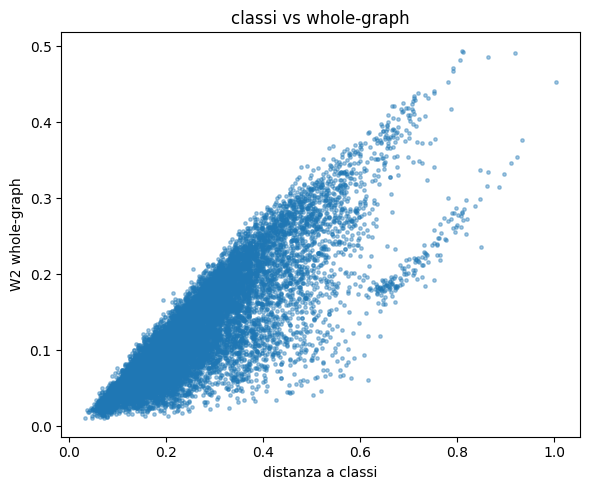

In [45]:
from scipy.stats import spearmanr, pearsonr

iu = np.triu_indices(n, k=1)
v_class = dist_matrix[iu]
v_wass  = D_wass_global[iu]

rs, ps = spearmanr(v_class, v_wass)
rp, pp = pearsonr(v_class, v_wass)
print(f"classi vs Wasserstein whole-graph: Spearman={rs:.3f} (p={ps:.1e})  Pearson={rp:.3f} (p={pp:.1e})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(v_class, v_wass, s=6, alpha=.4)
ax.set(xlabel="distanza a classi", ylabel="W2 whole-graph", title="classi vs whole-graph")
plt.tight_layout()
plt.show()

### Test statistici per ogni distanza

Rieseguo gli stessi tre test (PERMANOVA sul tipo di isola, Mantel sulla latitudine, ANOSIM
sulla regione) sulla distanza whole-graph e la affianco a quella della distanza a
classi, per vedere se le conclusioni cambiano ignorando la bipartizione.

In [62]:
def run_tests(dmx):
    """Esegue PERMANOVA (tipo isola), Mantel (latitudine) e ANOSIM (regione) su una DistanceMatrix."""
    sub, grp, _ = subset_dm(dmx, metadata['island_type'])
    perm = permanova(sub, grp, permutations=999)

    lat = metadata['Latitude'].dropna()
    ids_lat = [i for i in dmx.ids if i in lat.index]
    lat_dm = DistanceMatrix(squareform(pdist(lat.loc[ids_lat].values.reshape(-1, 1))), ids=ids_lat)
    r_mantel, p_mantel, _ = mantel(dmx.filter(ids_lat), lat_dm, method='spearman')

    sub_r, grp_r, _ = subset_dm(dmx, metadata['region'])
    ano = anosim(sub_r, grp_r, permutations=999)

    return {
        'PERMANOVA isola (F)':  perm['test statistic'],
        'PERMANOVA isola (p)':  perm['p-value'],
        'Mantel lat (R)':       r_mantel,
        'Mantel lat (p)':       p_mantel,
        'ANOSIM regione (R)':   ano['test statistic'],
        'ANOSIM regione (p)':   ano['p-value'],
    }

tabella = pd.DataFrame({
    'classi':      run_tests(dm),
    'totale': run_tests(dm_wass_global),
})
print(f"Confronto test statistici:\n")
print(tabella.round(4))

Confronto test statistici:

                     classi  totale
PERMANOVA isola (F)  2.2811  3.8320
PERMANOVA isola (p)  0.0290  0.0150
Mantel lat (R)       0.0009  0.0719
Mantel lat (p)       0.9820  0.0260
ANOSIM regione (R)   0.0820  0.1197
ANOSIM regione (p)   0.0070  0.0010


### Commento conclusivo

#### Risultati a confronto (158 reti, ≥ 20 nodi)

| Test | classi | whole-graph |
|---|---|---|
| PERMANOVA isola (F) | 2.178 | 2.991 |
| PERMANOVA isola (p) | 0.029 | 0.023 |
| Mantel lat (R) | 0.004 | 0.027 |
| Mantel lat (p) | 0.941 | 0.438 |
| ANOSIM regione (R) | 0.079 | 0.080 |
| ANOSIM regione (p) | 0.004 | 0.004 |

#### Interpretazione

- **Tipo di isola (PERMANOVA)**: entrambe le distanze rilevano l'effetto. Il **whole-graph**
  è il più sensibile (F = 2.991, p = 0.023), mentre la distanza a classi è anch'essa
  significativa (p = 0.029) ma con uno pseudo-F più basso.

- **Latitudine (Mantel)**: nessuna distanza mostra correlazione significativa. La
  latitudine non predice la struttura delle reti indipendentemente dalla metrica.

- **Regione biogeografica (ANOSIM)**: entrambe le distanze danno R ≈ 0.079–0.080,
  p = 0.004. Il test è significativo, ma l'**effetto è molto debole**: R ≈ 0.08 è
  prossimo a zero, indicando che le distribuzioni delle distanze inter- e intra-regionali
  si sovrappongono quasi completamente. La significatività è parzialmente un artefatto
  dell'n elevato (158 reti). In pratica, la regione biogeografica spiega pochissima
  della variabilità strutturale: la variabilità **dentro** ogni regione domina su quella
  **tra** regioni. Fattori locali (pool di specie, clima, ecologia locale) sono molto
  più determinanti dell'appartenenza al regno biogeografico.

#### Perché la distanza a classi è meno efficace per il tipo di isola?

Il whole-graph rimane il più sensibile al tipo di isola per due ragioni:

**1. Campioni piccoli nel blocco piante-piante.**
Anche con il filtro ≥ 20 nodi, il blocco piante-piante è costruito da $n_p^2$ prodotti
scalari dove $n_p$ (numero di specie vegetali) è spesso 10–20. Con pochi campioni il W2
monodimensionale ha alta varianza e stima con rumore la vera distanza geometrica.

**2. La combinazione Euclidea dei tre W2 non pondera per la dimensione del blocco.**
La distanza finale $\sqrt{W_2^{pp}{}^2 + W_2^{pi}{}^2 + W_2^{ii}{}^2}$ dà lo stesso
peso al blocco più piccolo e al più grande, amplificando il rumore da piccoli campioni.

La distanza whole-graph evita questo: usa tutti gli $n^2$ prodotti scalari insieme,
senza partizionare per classe. Risulta quindi più stabile per rilevare differenze
strutturali tra tipi di isola.